# PARAMETRIC METHOD

## Importing all Libraries

In [42]:
import numpy as np
import pandas as pd
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

## Setting Timeframe and Defining Tickers

In [43]:
years = 15

endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=365*years)

tickers = ['SPY', 'AAPL', 'TSLA', 'AMZN', 'MSFT']

In [44]:
print(endDate)
print(startDate)

2026-05-21 08:37:22.764767
2011-05-25 08:37:22.764767


## Downloading Adjusted Close Prices and Calculating Log Returns

In [45]:
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=startDate, end=endDate)
    adj_close_df[ticker] = data['Close'] #Extracting closing prices for each ticker

log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna() #Removing missing rows from log returns

/tmp/ipykernel_606/1652271393.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_606/1652271393.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_606/1652271393.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_606/1652271393.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=startDate, end=endDate)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_606/1652271393.py

In [46]:
print(log_returns)

                 SPY      AAPL      TSLA      AMZN      MSFT
Date                                                        
2011-05-26  0.004597 -0.005299  0.017106  0.014151  0.019649
2011-05-27  0.003827  0.007168  0.002372 -0.004472  0.003641
2011-05-31  0.010357  0.030415  0.019769  0.013101  0.010047
2011-06-01 -0.022717 -0.006692 -0.055248 -0.022052 -0.023465
2011-06-02 -0.001062  0.001706  0.008380  0.006476 -0.008633
...              ...       ...       ...       ...       ...
2026-05-14  0.007863 -0.002211 -0.004434 -0.010831  0.010361
2026-05-15 -0.012102  0.006751 -0.048673 -0.011593  0.030050
2026-05-18 -0.000704 -0.007992 -0.029441  0.002722  0.003832
2026-05-19 -0.006683  0.003787 -0.014446 -0.021061 -0.014555
2026-05-20  0.010197  0.010911  0.032022  0.021628  0.008682

[3768 rows x 5 columns]


## Creating an equally weighted portfolio and calculating historical returns

In [47]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)] * len(tickers))

historical_returns = (log_returns * weights).sum(axis=1) #Weighted average of all tickers in a portfolio

In [48]:
print(historical_returns)
0.2*(-0.000833-0.006631-0.003736-0.015148-0.000828)

Date
2011-05-26    0.010041
2011-05-27    0.002507
2011-05-31    0.016738
2011-06-01   -0.026035
2011-06-02    0.001373
                ...   
2026-05-14    0.000150
2026-05-15   -0.007113
2026-05-18   -0.006317
2026-05-19   -0.010592
2026-05-20    0.016688
Length: 3768, dtype: float64


-0.0054352

## Calculating X-Day Historical Returns

In [49]:
days = 5
historical_x_day_returns = historical_returns.rolling(window=days).sum()

## Creating Covariance Matrix and Calculation of Portfolio Standard Deviation

In [50]:
cov_matrix = log_returns.cov() * 252
portfolio_std_dev = np.sqrt(weights.T @ cov_matrix @ weights) #matrix multiplication

In [51]:
cov_matrix

,SPY,AAPL,TSLA,AMZN,MSFT
SPY,0.029730,0.033557,0.046100,0.034703,0.033412
AAPL,0.033557,0.080233,0.061667,0.044784,0.042202
TSLA,0.046100,0.061667,0.321316,0.069897,0.054954
AMZN,0.034703,0.044784,0.069897,0.107387,0.048760
MSFT,0.033412,0.042202,0.054954,0.048760,0.067941


In [52]:
portfolio_std_dev

np.float64(0.24873119979095498)

## Calculating VaR at different Confidence Intervals

In [53]:
confidence_levels = [0.9, 0.95, 0.99]

parametric_VaRs = []

for cl in confidence_levels:
  parametric_VaR =  portfolio_value * ((historical_returns.mean() * days) - (norm.ppf(1-cl) * portfolio_std_dev * np.sqrt(days / 252)))
  parametric_VaRs.append(parametric_VaR)

In [54]:
parametric_VaRs

[np.float64(49464.85335671876),
 np.float64(62193.51841495569),
 np.float64(86070.37718290283)]

## Plotting the Distribution of Portfolio Returns and Parametric VaR Estimates

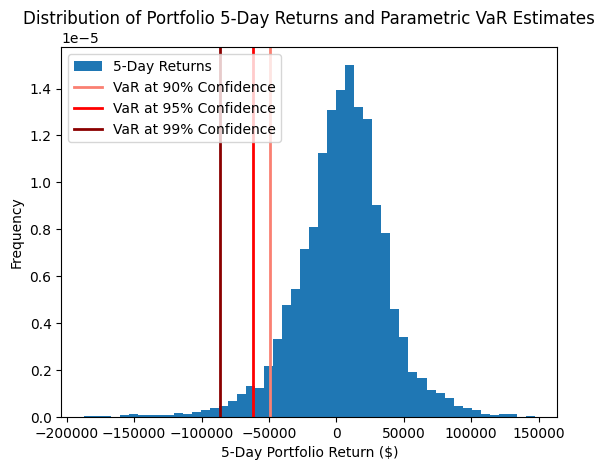

In [73]:
# Convert returns to dollar values for the histogram
historical_x_day_returns_dollar = historical_x_day_returns * portfolio_value

# Plot the histogram
plt.hist(historical_x_day_returns_dollar, bins=50, density=True, alpha=1, label=f'{days}-Day Returns')

# Add vertical lines representing VaR at each confidence level
colors = ['salmon','red', 'darkred']

for cl, parametric_VaR, color in zip(confidence_levels, parametric_VaRs, colors):

 plt.axvline(x = -parametric_VaR, linestyle='-', color = color, linewidth = 2, label = 'VaR at {}% Confidence'.format(int(cl * 100)))

plt.xlabel(f'{days}-Day Portfolio Return ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {days}-Day Returns and Parametric VaR Estimates')
plt.legend()
plt.show()


#  HISTORICAL METHOD

In [56]:
days = 5

return_window = days
range_returns = historical_returns.rolling(window = days).sum()
range_returns = range_returns.dropna()
print(range_returns)

Date
2011-06-02    0.004625
2011-06-03   -0.007809
2011-06-06   -0.027317
2011-06-07   -0.047664
2011-06-08   -0.031828
                ...   
2026-05-14    0.018373
2026-05-15   -0.000727
2026-05-18   -0.010959
2026-05-19   -0.012676
2026-05-20   -0.007184
Length: 3764, dtype: float64


In [57]:
confidence_levels = [0.9, 0.95, 0.99]
historical_VaRs = []

for cl in confidence_levels:
 historical_VaR = -np.percentile(range_returns, 100 - (cl * 100)) * portfolio_value
 historical_VaRs.append(historical_VaR)


In [58]:
print(historical_VaRs)

[np.float64(35474.661963649465), np.float64(49798.12004758754), np.float64(91437.80607677405)]


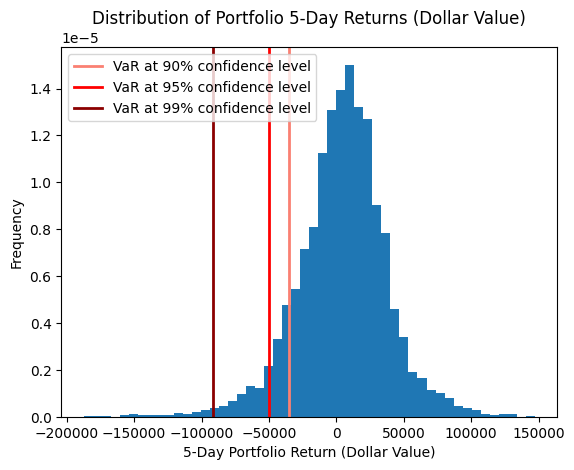

In [59]:

range_returns_dollar = range_returns * portfolio_value

colors = ['salmon','red', 'darkred']

plt.hist(range_returns_dollar.dropna(), bins=50, density=True)

for cl, historical_VaR, color in zip(confidence_levels, historical_VaRs, colors):
 plt.axvline(-historical_VaR, linestyle='-', color = color , linewidth=2, label=f'VaR at {cl:.0%} confidence level')

plt.xlabel(f'{return_window}-Day Portfolio Return (Dollar Value)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio {return_window}-Day Returns (Dollar Value)')

plt.legend()
plt.show()

# Monte Carlo Simulation

##  Create a function that will be used to calculate portfolio expected return and standard deviation

In [60]:
# We are assuming that future returns are based on past returns, which is not a reliable assumption.
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean()*weights)

def standard_deviation (weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [61]:
cov_matrix = log_returns.cov()
print(cov_matrix)

           SPY      AAPL      TSLA      AMZN      MSFT
SPY   0.000118  0.000133  0.000183  0.000138  0.000133
AAPL  0.000133  0.000318  0.000245  0.000178  0.000167
TSLA  0.000183  0.000245  0.001275  0.000277  0.000218
AMZN  0.000138  0.000178  0.000277  0.000426  0.000193
MSFT  0.000133  0.000167  0.000218  0.000193  0.000270


##  Calculating Portfolio Expected Return and Standard Deviation

In [62]:
portfolio_value = 1000000
weights = np.array([1/len(tickers)]*len(tickers))
portfolio_expected_return = expected_return(weights, log_returns)
portfolio_std_dev = standard_deviation (weights, cov_matrix)

## Defining Functions for Monte Carlo Simulation

In [63]:
def random_z_score():
    return np.random.normal(0, 1) #Generating random numbers from standard normal distribution(mean=0,std.dev=1)

# Create a function to calculate scenario Gain or Loss
days = 5

def scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days):
    return portfolio_value *((portfolio_expected_return * days) + (portfolio_std_dev * z_score * np.sqrt(days))) #Stochastic Differential Equation is used

##  Running Monte Carlo Simulation

In [64]:
# Run 100000 simulations
simulations = 100000
scenarioReturn = []

for i in range(simulations):
    z_score = random_z_score()
    scenarioReturn.append(scenario_gain_loss(portfolio_value, portfolio_std_dev, z_score, days))

In [65]:
scenarioReturn

[np.float64(6402.5746722676),
 np.float64(-5278.266085634531),
 np.float64(-3134.1124423668903),
 np.float64(29471.561253062016),
 np.float64(-58351.89130222579),
 np.float64(17231.345879130888),
 np.float64(-6989.119970885528),
 np.float64(-561.9690593830617),
 np.float64(17151.52786056455),
 np.float64(-28284.785631771087),
 np.float64(23676.401886378797),
 np.float64(2797.306478674592),
 np.float64(61309.312993093175),
 np.float64(-26425.52408627698),
 np.float64(3459.1773935448623),
 np.float64(11126.512105809768),
 np.float64(38312.09677895329),
 np.float64(4981.590703696177),
 np.float64(-14401.012839525476),
 np.float64(14234.092907355986),
 np.float64(-14615.00424274728),
 np.float64(14953.216258541397),
 np.float64(10860.504124405521),
 np.float64(4748.941748553069),
 np.float64(15045.085266621225),
 np.float64(-24854.950739090975),
 np.float64(5956.420837042027),
 np.float64(5102.850536980335),
 np.float64(63862.43662086126),
 np.float64(29600.16609383502),
 np.float64(-3052.

## Calculating VaR at different Confidence Intervals

In [66]:
confidence_levels = [0.9, 0.95, 0.99]
montecarlo_VaRs = []

for cl in confidence_levels:
 montecarlo_VaR = -np.percentile(scenarioReturn, 100 * (1 - cl))
 montecarlo_VaRs.append(montecarlo_VaR)

In [67]:
montecarlo_VaRs

[np.float64(40641.14174078264),
 np.float64(53108.23296688183),
 np.float64(76546.2413751709)]

## Plotting the results

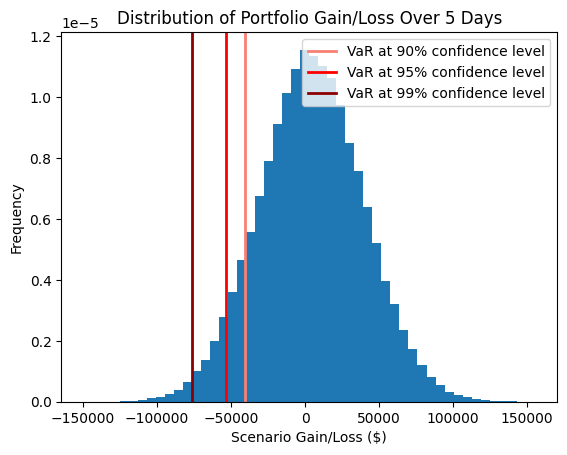

In [68]:
# Plot the results of all 100000 scenarios
plt.hist(scenarioReturn, bins=50, density=True)
plt.xlabel('Scenario Gain/Loss ($)')
plt.ylabel('Frequency')
plt.title(f'Distribution of Portfolio Gain/Loss Over {days} Days')

colors = ['salmon','red','darkred']
for cl, montecarlo_VaR, color in zip(confidence_levels, montecarlo_VaRs, colors):
 plt.axvline(-montecarlo_VaR, color=color, linestyle='-', linewidth=2, label=f'VaR at {cl:.0%} confidence level')
plt.legend()
plt.show()

# Comparing 5 day VaR by all 3 methods

In [69]:
VaR_table = pd.DataFrame({'Confidence Level': ['90%', '95%', '99%'], 'Parametric VaR': parametric_VaRs,'Historical VaR': historical_VaRs,'Monte Carlo VaR': montecarlo_VaRs})

In [70]:
VaR_table

,Confidence Level,Parametric VaR,Historical VaR,Monte Carlo VaR
0,90%,49464.853357,35474.661964,40641.141741
1,95%,62193.518415,49798.120048,53108.232967
2,99%,86070.377183,91437.806077,76546.241375


# Key Findings
### **VaR Increased with Higher Confidence Levels**

Across all three methodologies, the estimated VaR increased as the confidence level increased.

Observation:
- 90% confidence level produced the lowest VaR estimates
- 95% confidence level produced moderate VaR estimates
- 99% confidence level produced the highest VaR estimates

Interpretation:

Higher confidence levels aim to capture rarer and more extreme market losses. Therefore, as the confidence level increases, the estimated potential downside risk also increases.

 ### **Comparison of VaR Methodologies**

The project demonstrates that different VaR methodologies can produce materially different estimates of downside risk because each method relies on different assumptions and modeling techniques.

Key Observations:
- Historical VaR captured the most severe tail risk
- Parametric VaR produced analytically stable estimates
- Monte Carlo VaR offered flexible scenario-based estimation

The findings highlight the importance of understanding:

market behavior,
model assumptions,
distribution characteristics,
historical market events,





### **Final Conclusion**

This project successfully demonstrated the practical implementation and comparison of three major VaR methodologies used in financial risk management.

Overall, the project highlights that no single VaR model is universally perfect. Combining multiple approaches can provide a more comprehensive understanding of portfolio risk exposure and improve decision-making in financial risk management, banking, actuarial science, and investment analysis.